In [2]:
import numpy as np
import xarray as xr
# plottng
import cmocean as cmo
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.transforms import Bbox
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

import cartopy.crs as ccrs  # Projections list
import cartopy.feature as cfeature

import scipy
import scipy.stats as stats
from scipy.stats import pearsonr
from amocatlas import read


In [3]:
ds = read.calafat2025()

Loading 1 Calafat et al. 2025 dataset(s):
  0. Bayesian_estimates_Atlantic_MHT.zip: No description available



In [4]:
# 3 month averages startomg mid february 2004
#ends mid august 2020
print(ds.coords)
# ### idx = 0 == lat 65
# print(ds.lat.isel(lat=0))
# coordinates: TIME, LATITUDE
# where to access the index use TIME and lat

Coordinates:
    LATITUDE    (lat) float64 96B 65.0 60.0 55.0 45.0 ... -5.0 -11.0 -25.0 -35.0
  * TIME        (TIME) datetime64[ns] 536B 2004-02-14T23:59:59.999996901 ... ...
    LAT_BOUNDS  (lat, bound) float64 192B 67.5 62.5 62.5 ... -30.0 -30.0 -40.0


In [5]:
lats = ds.LATITUDE.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'N' if lat > 0 else 'S'}" for lat in lats]

In [6]:

def MHT_selection(ds, average=True, anomalies=False, one_band_sel=False, lat=None, statistics=False, ci=95, drop65=True, printout=False):
    """
    Select and process MHT data
    get anomalies and statistics,
    select a specific latitude band
    
    """
    def _name(da, label):
        da.name = label
        return da
    if drop65:
        ds = ds.where(ds.LATITUDE != 65, drop=True)
    lats = ds.LATITUDE.values
    MHT_prob = ds.MHT
    
    if printout:
        print("Initial MHT dims: ", MHT_prob.dims)
        nan_mask = np.isnan(MHT_prob).any(dim=["lat", "posterior_samples"])
        print("Timesteps with NaN: ", MHT_prob.TIME.where(nan_mask, drop=True).values)# Average over posterior samples or keep all
        
    MHT = MHT_prob.mean(dim="posterior_samples", skipna=True) if average else MHT_prob
    MHT_prob = MHT_prob.dropna(dim="TIME", how="any")  # Drop NaN timesteps from the probability data as well
    
    # Drop timesteps with any NaN
    MHT = MHT.dropna(dim="TIME", how="any")
    # get mean and std
    MHt = _name(MHT, "MHT (all bands)")
    statistics_results = None
    if statistics:
        mht_mean = MHT.mean(dim="TIME", skipna=True)
        mht_std = MHT.std(dim="TIME", skipna=True)
        
        mht_mean = _name(mht_mean, "MHT mean")
        mht_std = _name(mht_std, "MHT std")
        
        statistics_results = {
            "mean": mht_mean,
            "std": mht_std
        }
        
        if ci:
            
            lower_bound = MHT_prob.quantile((100 - ci) / 200, dim="posterior_samples", skipna=True) # this gives 2.5 for 95% CI
            upper_bound = MHT_prob.quantile(1 - (100 - ci) / 200, dim="posterior_samples", skipna=True) # this gives 97.5 for 95% CI
            
            lower_bound = lower_bound.mean(dim="TIME", skipna=True)
            upper_bound = upper_bound.mean(dim="TIME", skipna=True)
            
            lower_bound = _name(lower_bound, f"MHT {ci}% CI lower")
            upper_bound = _name(upper_bound, f"MHT {ci}% CI upper")
            if printout:
                print(f"{ci}% CI: {(100 - ci) / 200*100}% - {100 - (100 - ci) / 200*100}%")
            statistics_results["ci"] = np.array([mht_mean - lower_bound, upper_bound - mht_mean])
        
    # Anomalies
    mht_anom = None
    if anomalies:
        mht_mean = MHT.mean(dim="TIME", skipna=True)
        mht_anom = MHT - mht_mean
        mht_anom = _name(mht_anom, "MHT anomalies")

    # Latitude selection (applied to anomalies if available, else raw MHT)
    MHT_lat = None
    if one_band_sel:
        if lat is None:
            raise ValueError("Please provide a latitude value for one_band_sel.")
        lat_idx = np.argmin(np.abs(lats - lat))
        MHT_lat = MHT.isel(lat=lat_idx) 
        MHT_lat_anom = mht_anom.isel(lat=lat_idx) if anomalies else None
        MHT_lat = _name(MHT_lat, f"MHT lat {lat_labels[lat_idx]}")
        if anomalies:
            MHT_lat_anom = _name(MHT_lat_anom, f"MHT lat anom {lat_labels[lat_idx]}")
        if printout:
            print(f"Selected latitude: {lats[lat_idx]}°N")

    
    if printout:
        target = mht_anom if anomalies else MHT
        print(f"Output shape: {target.shape}")
        print(f"Any NaNs: {np.isnan(target).any().item()}")
        lat_sel = MHT_lat
        print(f"Latitude selection shape: {lat_sel.shape if lat_sel is not None else 'N/A'}")

    return {
        "lats" : lats,
        "MHT": MHT,
        "MHT_anom": mht_anom,
        "MHT_lat": MHT_lat,
        "MHT_lat_anom": MHT_lat_anom if anomalies else None,
        "MHT_statistics": statistics_results
    }
    
MHT_dict = MHT_selection(ds, average=True, anomalies=True, one_band_sel=True, lat=26, statistics=True , ci=90, printout=True)    

lats = MHT_dict["lats"]
mht = MHT_dict["MHT"]
mht_anom = MHT_dict["MHT_anom"]
mht_26 = MHT_dict["MHT_lat"]
mht_26_anom = MHT_dict["MHT_lat_anom"]
mht_mean = MHT_dict["MHT_statistics"]["mean"]
mht_std = MHT_dict["MHT_statistics"]["std"] 
mht_ci = MHT_dict["MHT_statistics"]["ci"] 

Initial MHT dims:  ('lat', 'TIME', 'posterior_samples')
Timesteps with NaN:  ['2004-02-14T23:59:59.999996901']
90% CI: 5.0% - 95.0%
Selected latitude: 26.0°N
Output shape: (11, 66)
Any NaNs: False
Latitude selection shape: (66,)


In [7]:
ds_rapid_transport = read.rapid()
ds_rapid_transport

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



<xarray.Dataset> Size: 1MB
Dimensions:           (TIME: 14599)
Coordinates:
  * TIME              (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Data variables:
    TRANS_0_800       (TIME) float64 117kB ...
    TRANS_800_1100    (TIME) float64 117kB ...
    TRANS_1100_3000   (TIME) float64 117kB ...
    TRANS_3000_5000   (TIME) float64 117kB ...
    TRANS_below_5000  (TIME) float64 117kB ...
    TRANS_FC          (TIME) float64 117kB ...
    TRANS_EKMAN       (TIME) float64 117kB ...
    TRANS_UMO         (TIME) float64 117kB ...
    MOC               (TIME) float64 117kB ...
Attributes: (12/39)
    title:                                 RAPID MOC timeseries
    summary:                               RAPID 26N transport estimates dataset
    description:                           RAPID 26N transport estimates dataset
    program:                               RAPID
    project:                               RAPID-AMOC 26°N array
    license:                               UK Open Government Licence v3.0 ht...
    ...                                    ...
    processing_datasource:                 rapid26n
    variable_mapping:                      {'time': 'TIME', 't_therm10': 'TRA...
    original_variable_metadata:            {'t_therm10': {'long_name': 'Trans...
    applied_variable_mapping:              {'time': 'TIME', 't_therm10': 'TRA...
    version:                               v2024.1a
    files:                                 {'moc_transports.nc': {'featureTyp...

In [8]:
# data
calafat_start = ds.isel(TIME=0).TIME.values
calafat_end = ds.isel(TIME=-1).TIME.values
# open rapid data
ds_rapid = xr.open_dataset("/Users/leadietz/Desktop/uni/masterthesis/coding/rapid/meridional_transports.nc")
mht_rapid = ds_rapid.heat_trans 
# change to be 2004-2020 as calafat data
mht_rapid = mht_rapid.sel(time=slice(calafat_start, calafat_end))
mht_rapid_mean = mht_rapid.mean(dim="time", skipna=True)

mht_rapid_mean #= mht_rapid_mean.rename("MHT Rapid mean")


### for the CONFIDENCE INTERVALS

## they do some calculations to remove seasonal bias
ds_rapid

<xarray.Dataset> Size: 10MB
Dimensions:        (time: 730, depth: 307, sigma0: 631, sigma2: 708)
Coordinates:
  * time           (time) datetime64[ns] 6kB 2004-04-06 ... 2024-03-22
  * depth          (depth) float64 2kB 0.0 19.87 39.73 ... 5.976e+03 5.995e+03
  * sigma0         (sigma0) float64 5kB 1.022e+03 1.022e+03 ... 1.028e+03
  * sigma2         (sigma2) float64 6kB 1.03e+03 1.03e+03 ... 1.037e+03
Data variables:
    amoc_depth     (time) float64 6kB ...
    amoc_sigma0    (time) float64 6kB ...
    amoc_sigma2    (time) float64 6kB ...
    heat_trans     (time) float64 6kB ...
    frwa_trans     (time) float64 6kB ...
    pressure       (depth) float64 2kB ...
    stream_depth   (time, depth) float64 2MB ...
    stream_sigma0  (time, sigma0) float64 4MB ...
    stream_sigma2  (time, sigma2) float64 4MB ...
Attributes:
    Project:                RAPID-MOCHA-WBTS
    Website:                http://www.rapid.ac.uk/
    Dataset_version:        v2024-1a
    time_coverage_start:    2004-04-06
    time_coverage_end:      2024-03-22
    Dataset_creation_date:  26-Jan-2026 14:06:26
    File_creation_date:     2026-01-26
    DOI:                    10.5285/48d0bf43-0598-ceb2-e063-7086abc062f1
    Citation:               Moat B.I.; Smeed D.A.; Rayner D.; Johns W.E.; Smi...
    Acknowledgement:        The RAPID AMOC observing project is funded by the...

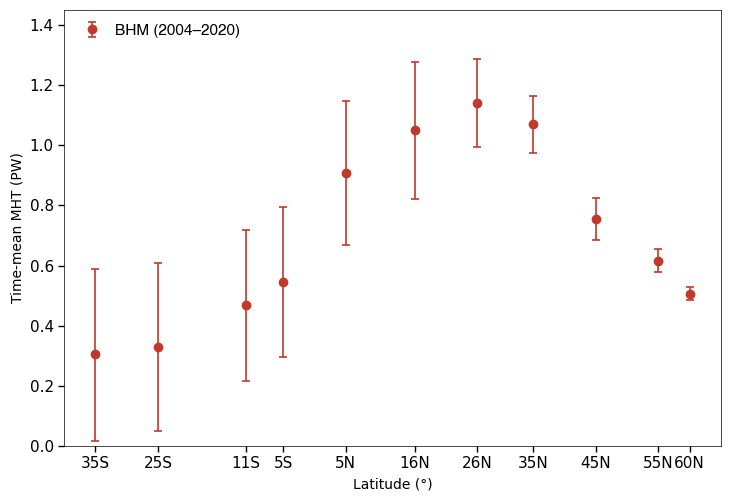

In [9]:

# plotting

fig, ax = plt.subplots(figsize=(7.5, 5.2))

plt.rcParams.update({
    "font.family":  "Helvetica",   
    "font.size":    13,
    "axes.linewidth": 1.0,
})

ax.spines["left"].set_linewidth(0.5)
ax.spines["right"].set_linewidth(0.5)
ax.spines["top"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

ax.errorbar(
    lats, mht_mean,
    yerr=mht_ci,
    fmt="o",
    color="#C0392B",
    markerfacecolor="#C0392B",
    markersize=6,
    ecolor="#C0392B",
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
    zorder=5,
    label="BHM (2004–2020)",
)
    
# ax.scatter(
#     lats, mht_mean,
#     color="#C0392B",       # fill colour of the dots
#     edgecolors="#8B1A1A",  # outline colour
#     s=40,                  # marker size (points²)
#     zorder=5,
#     label="BHM (2004–2020)",
# )

ax.set_ylabel("Time-mean MHT (PW)")
ax.set_xlabel("Latitude (°)")
ax.set_ylim(0.0, 1.45)
ax.set_xlim(-40, 65)

xtick_pos    = [-35, -25, -11, -5,  5,  16, 26, 35, 45, 55, 60]
xtick_labels = ["35S","25S","11S","5S","5N","16N","26N","35N","45N","55N","60N"]
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, fontsize=11)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis="both", which="major", length=4, width=1.0, labelsize=11)

legend = ax.legend(
    loc="upper left",
    frameon=False,         
    fontsize=11,
    handlelength=1.8,
    handletextpad=0.6,
    labelspacing=0.4,
)

plt.tight_layout()
# plt.savefig("mht_plot.pdf", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ## figure fr transport anomalies as in calafat paper
# withuderlying atlantic map
# fig = plt.figure(figsize=(10, 14))

# # GridSpec: one row per latitude
# gs = gridspec.GridSpec(n_lats, 1, hspace=0, figure=fig)
# axes = [fig.add_subplot(gs[i]) for i in range(n_lats)]

# # --- Background Atlantic map ---
# # Draw it as a low-opacity inset covering the whole figure
# map_ax = fig.add_axes([0.12, 0.05, 0.78, 0.93],  # [left, bottom, width, height]
#                        projection=ccrs.PlateCarree())
# map_ax.set_extent([-100, 20, -45, 70], crs=ccrs.PlateCarree())  # Atlantic bounds
# map_ax.add_feature(cfeature.LAND,  facecolor='lightgray', alpha=0.35, zorder=0)
# map_ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.15, zorder=0)
# map_ax.add_feature(cfeature.COASTLINE, linewidth=0.3, alpha=0.3, zorder=0)
# map_ax.spines['geo'].set_visible(False)
# map_ax.patch.set_visible(False)
# map_ax.set_zorder(0)  # push behind everything

# # --- Plot each latitude ---
# ylim = (-0.8, 0.8)  # adjust to your data range


# for i, (lat, lat_label) in enumerate(zip(lats, lat_labels)):
#     lat = int(lat)
#     print(f"index, lat, label: {i}, {lat}, {lat_label}")
#     ax = axes[i]
#     y = mht_anom.isel(lat=i).values

#     ax.plot(time, y, color='darkred', linewidth=0.8)
#     ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
#     ax.set_ylim(ylim)
#     ax.set_xlim(time[0], time[-1])
#     ax.set_zorder(1)          # above the map
#     ax.patch.set_alpha(0.0)   # transparent background so map shows through

#     # Left y-axis: lat label + tick marks
#     ax.set_yticks([ylim[0], 0, ylim[1]])
#     ax.set_yticklabels([f'{ylim[0]}', '0.0', f'{ylim[1]}'], fontsize=6)
#     ax.yaxis.set_label_position('left')
#     ax.set_ylabel(lat_label, rotation=0, labelpad=30, fontsize=8, va='center')

#     # # Right y-axis: mirror ticks
#     # ax2 = yticks([ylim[0], 0, ylim[1]])
#     # ax2.set_ax.twinx()
#     # ax2.set_ylim(ylim)
#     # ax2.set_yticklabels([f'{ylim[0]}', '0.0', f'{ylim[1]}'], fontsize=6)
#     # ax2.set_zorder(1)
#     # ax2.patch.set_alpha(0.0)

#     # Remove x ticks on all but the bottom
#     if i < n_lats - 1:
#         ax.set_xticklabels([])
#     else:
#         ax.tick_params(axis='x', labelsize=8)

# # --- Labels ---
# axes[-1].set_xlabel("Time", fontsize=10)
# fig.text(0.01, 0.5, "MHT anom. (PW)", va='center', rotation='vertical', fontsize=10)
# fig.suptitle("Quarterly MHT anomalies", fontsize=12, y=1.01)

# plt.savefig("mht_stacked.png", dpi=150, bbox_inches='tight')
# plt.show()
   

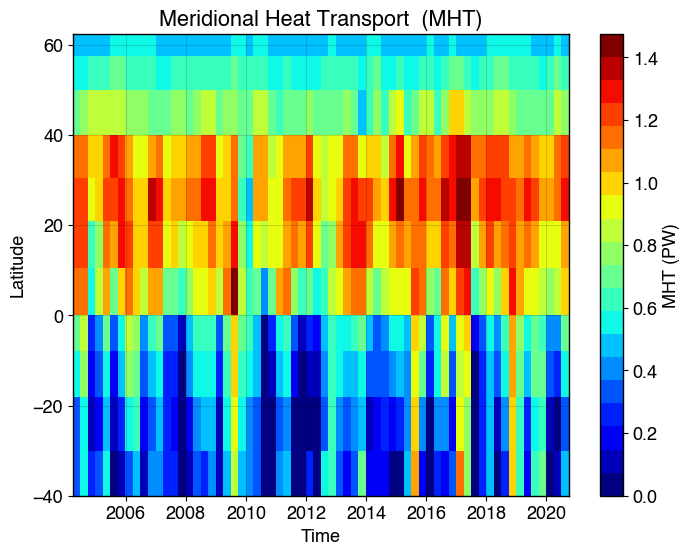

In [11]:
def plot_transport(MHT, lats, cmap="bwr", vmin=None, vmax=None, savefig=False):
    """
    Plot the MHT (can be anomalies or raw) as a function of time and latitude using a colormap.
    """
    plt.figure(figsize=(8, 6))

    if vmin is None and vmax is None:
        vmin = np.nanmin(MHT.values)
        vmax = np.nanmax(MHT.values)
        limit = max(abs(vmin), abs(vmax))
        vmin = -limit #- 0.5
        # vmin  = 0 
        vmax = limit #+ 0.5
    
    # plt.pcolormesh(mht_anom.TIME, lats, mht_anom.values, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    # plt.pcolormesh(MHT.TIME, lats, MHT.values, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    plt.pcolormesh(MHT.TIME, lats, MHT.values, shading='auto', cmap=cmap, vmin=0, vmax=vmax)
    plt.colorbar(label='MHT (PW)')
    plt.xlabel('Time')
    # plt.yticks(lats, lat_labels)
    plt.ylabel('Latitude')
    plt.grid(alpha=0.15, linestyle='-', color="black")
    # plt.title('Meridional Heat Transport Anomalies (MHT)')
    plt.title('Meridional Heat Transport  (MHT)')
    if savefig:
        plt.savefig("figures/mht_time_lat.png", dpi=300, bbox_inches='tight')
    plt.show()

# cmap = cmo.cm.deep
cmap = plt.get_cmap("jet")
# cmap = plt.get_cmap("bwr")
colors = cmap(np.linspace(0, 1, 20))
sliced_cmap = ListedColormap(colors)

plot_transport(mht, lats, cmap=sliced_cmap, savefig=True)
# hoevmeller diagram? 
# plot anomla yto this - trel to time mean ? polot animaly of NAO (bwr colormap)

# colormap : jaeger papper 2013 
# colorbrewer 

## Correlation things

In [12]:
#cross correlation plot between latitude bands
MHT_copy = mht.rename(lat="lat2")

corr = xr.corr(mht, MHT_copy,  dim="TIME") 
# print("any nan in the correlation matrix:", np.isnan(corr).any()) # True! still nans in the correlation matrix, but not in MHT itself

## cross correlation plot lat - lat

In [13]:
lats

array([ 60.,  55.,  45.,  35.,  26.,  16.,   5.,  -5., -11., -25., -35.])

ValueError: The number of FixedLocator locations (11), usually from a call to set_ticks, does not match the number of labels (12).

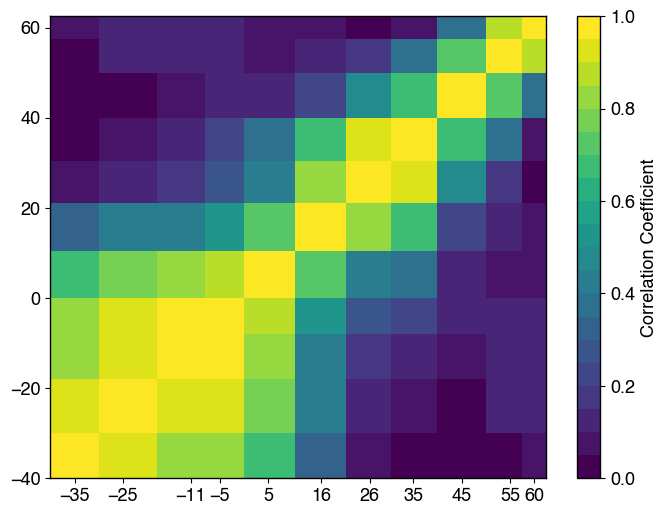

In [14]:
# MHT_copy_anom = mht_anom.rename(lat="lat2")

# corr_anom = xr.corr(mht_anom, MHT_copy_anom,  dim="TIME") 
# corr = corr_anom
fig = plt.figure(figsize=(8, 6))
cmap = plt.get_cmap("viridis")

colors = cmap(np.linspace(0, 1, 20))
# colors = cmap(np.linspace(0.5, 1, 10))
sliced_cmap = ListedColormap(colors)

plt.pcolormesh(lats, lats, corr, cmap=sliced_cmap, vmin=0, vmax=1)
# plt.pcolormesh(lats, lats, corr, cmap=sliced_cmap, vmin=0.5, vmax=1)
# origin lower put origin at bottom left, extent to set the axis limits to latitudes
plt.colorbar(label='Correlation Coefficient')

# nan_mask = np.isnan(corr).astype(float)
# plt.contourf(lats, lats, nan_mask, levels=[0.9, 1.1], 
#              hatches=['////'], colors='none', label='NaN Mask')
# levels : to have contourf just draw the hatches where is 1 = True = there is nan

plt.xticks(lats, lat_labels, rotation=45)
plt.yticks(lats, lat_labels)
# plt.xlim(lats[0], lats[7])
# plt.ylim(lats[0], lats[7])
# plt.xlim(0, lats[0])
# plt.ylim(0, lats[0])


plt.xlabel('Latitude (°N)')
plt.ylabel('Latitude (°N)')
plt.title('Cross-Correlation of MHT between Latitude Bands')
plt.savefig("figures/cross_corr/mht_correlation_latlat.png", dpi=300, bbox_inches='tight')
plt.show()

## 0 lag correlation between 26°N and rest? 

In [ ]:
mht_26.LATITUDE.values.item()

26.0

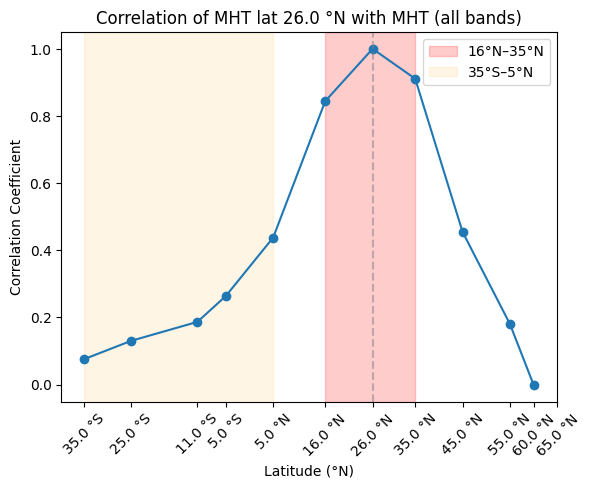

In [ ]:
def zero_lag_corr(ts1, ts2, dimension="TIME", plot=False, savefig=False, polar_band=False):
    """
    Compute the zero-lag Pearson correlation coefficient between two time series and plot the result as a function of latitude.
    
    """
    corr = xr.corr(ts1, ts2,  dim=dimension) 
    if plot:
        fig, ax = plt.subplots()
        ax.plot(lats, corr, marker='o')

        ax.set_xticks(lats)
        ax.set_xticklabels(lat_labels, rotation=45)
        ax.set_xlabel('Latitude (°N)')
        ax.set_ylabel('Correlation Coefficient')
        if ts1.LATITUDE.size == 1:
            # then its one selected latitude band
            lat_sel = ts1.LATITUDE.values.item()
            ax.axvline(lat_sel, color='gray', linestyle='--', alpha=0.5)
        
        # 2 latitde bands with high inner covariability 
        band1_min, band1_max = 16, 35      # 16N–35N
        band2_min, band2_max = -35, 5      # 35S–5N
        band3_min, band3_max = 55, 65      # 55-65N
        
        y_min, y_max = ax.get_ylim()

        # Rectangle for 16N–35N
        rect1 = mpatches.Rectangle(
            (band1_min, y_min),
            band1_max - band1_min,
            y_max - y_min,
            color='red',
            alpha=0.2,
            label='16°N–35°N'
        )

        # Rectangle for 35S–5N
        rect2 = mpatches.Rectangle(
            (band2_min, y_min),
            band2_max - band2_min,
            y_max - y_min,
            color='orange',
            alpha=0.1,
            label='35°S–5°N'
        )
        ax.add_patch(rect1)
        ax.add_patch(rect2)
        
        if polar_band:
            
            rect3 = mpatches.Rectangle(
                (band3_min, y_min),
                band3_max - band3_min,
                y_max - y_min,
                color='magenta',
                alpha=0.1,
                label='55°N–65°N'
            )
            ax.add_patch(rect3)
        
        ax.legend(loc='best')
        
        ax.set_title(f"Correlation of {ts1.name} with {ts2.name}")

        if savefig:
            plt.savefig(f"figures/cross_corr/corr_{ts1.name}_{ts2.name}.png", dpi=300, bbox_inches='tight')
        plt.show()
    return corr

_ = zero_lag_corr(mht_26, mht, plot=True, savefig=True)

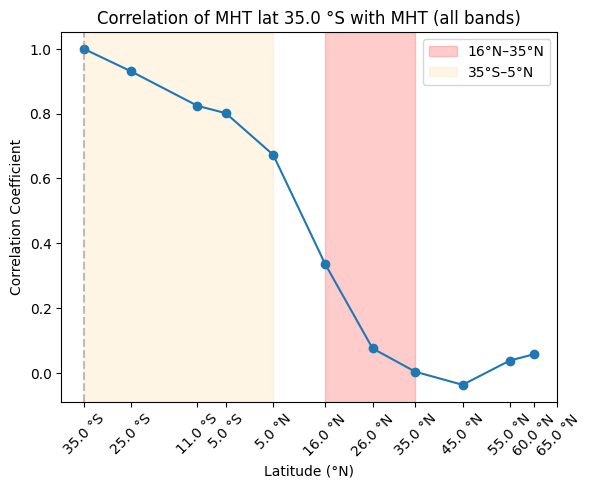

In [ ]:
# mht_25S = MHT_selection(ds, one_band_sel=True, lat=-25)["MHT_lat"]
# corr_25S_all = zero_lag_corr(mht_25S, mht, plot=True, savefig=True)

mht_35S = MHT_selection(ds, one_band_sel=True, lat=-35)["MHT_lat"]
corr_35S_all = zero_lag_corr(mht_35S, mht, plot=True, savefig=True)

# mht_60 = MHT_selection(ds, one_band_sel=True, lat=60)["MHT_lat"]
# corr_60_all = zero_lag_corr(mht_60, mht, plot=True, savefig=False, polar_band=True)
